# 08 - Community Detection

Up to this point we've treated Israel's public-transport network as one object and asked how fragile it is. This notebook asks a different question: **does the network split, on its own, into blocks that are well connected on the inside?** We run the **Louvain** algorithm for modularity maximization on the undirected, weighted trip-adjacency graph, measure how good the resulting partition is (**modularity**), describe the communities it finds, and then identify the **inter-community bridge stations** - the stations whose neighbors sit in more than one community, and which therefore carry the traffic that's forced to cross a boundary between communities.

**The research question here:** is the network a collection of loosely connected regional/metropolitan clusters rather than one homogeneous network, and which stations hold those clusters together?

### A contradiction this notebook was written to resolve

Two earlier records of the project disagree with each other: the Hebrew summary report says Louvain found **91** communities, while the presentation's pipeline reports **73**. Neither number is wrong in the sense of being a mistake - Louvain is a *stochastic greedy heuristic*, so the number of communities it returns isn't a fixed property of the graph. It depends on the random seed, the resolution parameter, the implementation, and the exact graph it was given. So this notebook:

1. exposes `LOUVAIN_SEED` and `LOUVAIN_RESOLUTION` as explicit constants at its head,
2. reports what **this** run produces, together with its modularity, instead of quoting a number remembered from the past,
3. runs a seed sweep and a resolution sweep to show empirically how much the number moves while the partition itself stays essentially the same,
4. explains, in section 8, which of these mechanisms could produce the order-of-magnitude gap seen between the two earlier records.

No community count and no community id is hard-coded in the code or the text anywhere below; every number and every label is computed from the data at run time.

## Input

* `outputs/nb/02_graph_construction/nodes.csv` - one row per active station, with `stop_id, stop_name, lat, lon, region, metro`.
* `outputs/nb/02_graph_construction/edges.csv` - one row per **directed** segment `from_stop, to_stop, trip_frequency`.

Both files are produced by the `02_graph_construction` notebook. This notebook does **not** read the raw GTFS file, does **not** need the 816 MB `stop_times.txt`, and does **not** import anything from `src/` or from `public_transport_network_research/` - all the logic is built in.

## Output

Everything is written under `outputs/nb/08_community_detection/`:

* `community_detection_summary.json` - the key statistics (seed, resolution, backend, community count, modularity, boundary statistics) in one dictionary.
* `tables/community_assignments.csv` - one row per station with its Louvain community (and alongside it its label propagation community, for comparison).
* `tables/community_summary.csv` - one row per community: size, internal/external edges and weight, centroid, dominant region and metro, hub station, and the derived label.
* `tables/inter_community_bridges.csv` - every station whose neighborhood spans more than one community, ranked by the number of communities it touches.
* `tables/louvain_stability.csv` - the results of the seed sweep and the resolution sweep (community count, modularity, and the degree of agreement with the main run).
* `tables/community_detection_summary.csv` - the key statistics as a single-row table.
* `figures/community_map_louvain.png` - all stations plotted at their real coordinates, colored by community.
* `figures/community_size_distribution.png` - the largest communities as a bar chart, plus the full rank-size distribution.
* `figures/inter_community_bridges_map.png` - the boundary-crossing stations, on top of the map.
* `figures/louvain_stability.png` - community count and modularity across seeds and resolutions.

## 1. Setting up the runtime environment

The cell below lets the notebook run both on a local copy of the repository and on Google Colab. It defines `_ensure(...)`, which pip-installs only the packages that are actually missing (so re-running the notebook is cheap), and `find_repo_root()`, which climbs upward from the current directory looking for the GTFS folder, and if it doesn't find it, clones the repository into `/content`. It then sets `REPO`, `DATA`, and `OUT` and creates the notebook's output root. Every later cell relies on these three paths, so this cell has to run first. It's the same setup used across all the other notebooks in the series, kept identical on purpose so each one can be run independently.

In [ ]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)


## 2. Libraries, stage folders, and tunable constants

We install and import the scientific library stack, then fix this stage's folder layout. Following the project convention, each notebook owns exactly one output folder: this notebook writes to `outputs/nb/08_community_detection/` (with the `tables/` and `figures/` subfolders) and reads the previous stage from `outputs/nb/02_graph_construction/`.

In a Python environment there are two implementations of Louvain, and they do **not** always return the same partition: the standalone `python-louvain` package (imported as `community`, the one the project's original script used) and the implementation bundled with `networkx` since version 2.8. We prefer the first for continuity with the previous pipeline, and fall back to the second if the package can't be installed - the choice is recorded in `LOUVAIN_BACKEND` and written to the summary JSON, because "which implementation" is itself one of the explanations for the gap between 91 and 73.

The constants are gathered here so a reviewer can change the experiment in one place:

* `LOUVAIN_SEED` - the random number generator's seed in the main run. Louvain scans the nodes in random order and breaks ties randomly, so this constant really does change the answer. Fixing it makes the notebook reproducible.
* `LOUVAIN_RESOLUTION` - the `gamma` parameter in the modularity objective. The value `1.0` is the classic Newman-Girvan setting; values above 1 penalize large communities and so return many smaller communities; values below 1 return fewer, larger ones.
* `SEED_SWEEP` / `RESOLUTION_SWEEP` - the two sensitivity experiments of section 8.
* `RUN_LABEL_PROPAGATION` - an extra run of a second, completely different community algorithm, as a cross-check.
* The remaining parameters control figure resolution and the number of rows shown in tables and top-N charts.

Running Louvain on a graph of about 30k nodes / 52k edges takes a few seconds per run, so the sweeps below cost about a dozen runs and still finish well under a minute.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn', 'scikit-learn')

import json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

# Prefer python-louvain when it is already installed. It is optional: NetworkX
# provides the same algorithm, so a missing package must never trigger a slow install.
try:
    import community as community_louvain
    LOUVAIN_BACKEND = 'python-louvain'
except ImportError:
    community_louvain = None
    LOUVAIN_BACKEND = 'networkx'

PREV = OUT / '02_graph_construction'      # read-only: artifacts of notebook 02
STAGE = OUT / '08_community_detection'    # everything this notebook produces
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ----------------------------------------------------
LOUVAIN_SEED = 42                              # RNG seed of the headline run
LOUVAIN_RESOLUTION = 1.0                       # gamma in the modularity objective
SEED_SWEEP = [0, 1, 7, 42, 123, 2024]          # seeds tried in the stability experiment
RESOLUTION_SWEEP = [0.5, 0.8, 1.0, 1.2, 2.0]   # resolutions tried at the fixed seed
RUN_LABEL_PROPAGATION = True                   # second algorithm, used only as a cross-check
WEIGHT_ATTR = 'weight'                         # edge attribute Louvain optimises over
FIG_DPI = 150                                  # figure resolution; drop to 90 for smaller files
TOP_N = 20                                     # rows shown in every top-N table / bar chart
MAP_ALPHA = 0.6                                # point transparency on the ~30k-point maps
MAP_POINT_SIZE = 3                             # marker size on the community map
ANNOTATE_TOP = 8                               # communities labelled in place on the map

print('previous stage :', PREV)
print('this stage     :', STAGE)
print('Louvain backend:', LOUVAIN_BACKEND)
print(f'seed = {LOUVAIN_SEED}, resolution = {LOUVAIN_RESOLUTION}')


previous stage : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction
this stage     : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\08_community_detection
Louvain backend: python-louvain
seed = 42, resolution = 1.0


## 3. Handling Hebrew labels

The station names in the Israeli GTFS file are in Hebrew, and several of the figures below display them (the community bar chart labels each community with its busiest station). Matplotlib doesn't implement Unicode's bidirectional algorithm, so right-to-left text comes out reversed and unreadable. The cell below applies a one-time monkey-patch to `matplotlib.text.Text.set_text`, so that any string containing Hebrew characters is converted to display order using `python-bidi` before it's drawn, and picks a font that actually has Hebrew glyphs (Arial on Windows, DejaVu Sans everywhere else). The cell is idempotent - re-running it won't stack patches on top of each other. All the rest of the text in the notebook is in English, per the submission requirements.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We must NOT pre-reorder it with python-bidi - that would reverse it a second time. So
# fix_he is a no-op and we only select a Hebrew-capable font. (If Hebrew ever renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()


## 4. Loading the graph produced in notebook 02

This stage depends on the `02_graph_construction` notebook. Rather than restore a `networkx` object from a pickle file (pickle files are version-sensitive and unreadable to a reviewer), we reload the two plain CSV tables that stage 02 exports and rebuild the graph from them - the CSV files contain exactly the same information. This is a deliberate change from the project's original script, which loaded `graph_undirected.pkl`. The `find_artifact` function scans the entire previous-stage folder, so it works whether stage 02 put the tables at the folder root or inside `tables/`, and raises an explicit, actionable error if the output files are missing.

In [4]:
# --- Locate the artifacts written by notebook 02 --------------------------
def find_artifact(stage_dir, filename):
    """Return the path of `filename` under a stage folder, or None if absent."""
    if not stage_dir.is_dir():
        return None
    direct = stage_dir / filename
    if direct.exists():
        return direct
    matches = sorted(stage_dir.rglob(filename))
    return matches[0] if matches else None

nodes_path = find_artifact(PREV, 'nodes.csv')
edges_path = find_artifact(PREV, 'edges.csv')
missing = [name for name, p in [('nodes.csv', nodes_path), ('edges.csv', edges_path)] if p is None]
if missing:
    raise FileNotFoundError(
        f"{', '.join(missing)} not found under {PREV} - "
        'run notebook 02_graph_construction first; it writes nodes.csv and edges.csv.'
    )

nodes_df = pd.read_csv(nodes_path, dtype={'stop_id': str}, encoding='utf-8-sig')
edges_df = pd.read_csv(edges_path, dtype={'from_stop': str, 'to_stop': str}, encoding='utf-8-sig')
print(f'nodes: {len(nodes_df):,} rows  <-  {nodes_path}')
print(f'edges: {len(edges_df):,} rows  <-  {edges_path}')
nodes_df.head()


nodes: 30,463 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\nodes.csv
edges: 51,999 rows  <-  C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\02_graph_construction\tables\edges.csv


,stop_id,stop_name,lat,lon,region,metro,stop_use_count
0,38725,ת. רכבת יבנה מערב,31.890700,34.731191,Center,Tel Aviv,1370
1,15582,שד. הסנהדרין/שד. ירושלים,31.887865,34.734514,Center,Tel Aviv,228
2,15746,שד. ירושלים/שד. הסנהדרין,31.887569,34.733548,Center,Tel Aviv,742
3,15725,בית ספר אורמת/נחל חריף,31.894514,34.734783,Center,Tel Aviv,84
4,15416,מחלף בית רבן למזרח,31.819528,34.730697,Center,Tel Aviv,832


## 5. Rebuilding the weighted undirected graph

The project's model is a **trip-adjacency graph**: a node is a station that appears in at least one trip, and a directed edge `u -> v` exists when some trip visits `v` immediately after `u`; the edge weight is the number of trips that use that segment. The `edges.csv` file stores this directed graph. Community detection is defined for undirected graphs, so we take the undirected projection: one edge per unordered pair, with the weights of the two travel directions **summed**. This summed weight is what Louvain maximizes over, which means a segment served by a hundred buses an hour pulls its two endpoints into the same community far more strongly than a segment served twice a day - the partition is about service intensity, not just topology.

Station attributes (name, coordinates, region, metro) are joined in from `nodes.csv`. The `_num` and `_txt` helper functions safely convert empty values and `NaN`, so a missing coordinate becomes `None` rather than a silent `NaN` that would later be plotted at a meaningless location.

In [5]:
# --- Rebuild the weighted undirected graph ---------------------------------
def _num(value):
    """Coerce to float; return None for blanks, NaN or non-numeric input."""
    if value is None:
        return None
    try:
        f = float(value)
    except (TypeError, ValueError):
        return None
    return None if not np.isfinite(f) else f


def _txt(value):
    """Coerce to a plain string; NaN and None become an empty string."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return ''
    return str(value)


def build_undirected_graph(nodes_df, edges_df):
    """Undirected projection of the directed trip graph; opposite-direction weights summed."""
    attr = {}
    for rec in nodes_df.to_dict('records'):
        attr[str(rec.get('stop_id'))] = {
            'stop_name': _txt(rec.get('stop_name')),
            'lat': _num(rec.get('lat')),
            'lon': _num(rec.get('lon')),
            'region': _txt(rec.get('region')),
            'metro': _txt(rec.get('metro')),
        }

    weight_col = next((c for c in ('trip_frequency', 'weight', 'count')
                       if c in edges_df.columns), None)

    G = nx.Graph()
    for rec in edges_df.to_dict('records'):
        u, v = str(rec['from_stop']), str(rec['to_stop'])
        if u == v:
            continue
        w = int(rec[weight_col]) if weight_col else 1
        if G.has_edge(u, v):
            G[u][v][WEIGHT_ATTR] += w
        else:
            G.add_edge(u, v, **{WEIGHT_ATTR: w})

    default = {'stop_name': '', 'lat': None, 'lon': None, 'region': '', 'metro': ''}
    for n in G.nodes():
        G.nodes[n].update(attr.get(n, default))
    return G


G = build_undirected_graph(nodes_df, edges_df)
total_weight = sum(d[WEIGHT_ATTR] for _, _, d in G.edges(data=True))
unnamed = sum(1 for n in G.nodes() if not G.nodes[n]['stop_name'])
print(f'undirected G : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'total edge weight (trips over all segments): {total_weight:,}')
print(f'nodes with no name attribute: {unnamed:,}')


undirected G : 30,463 nodes, 51,772 edges
total edge weight (trips over all segments): 15,290,773
nodes with no name attribute: 0


## 6. Restricting the analysis to the largest connected component

The project's original script ran Louvain on `G.subgraph(max(nx.connected_components(G), key=len))`, that is, on **the largest connected component only**, and we keep that choice. The reasoning is that isolated components are trivially a community of their own: a six-station "island" that touches nothing *must* be a separate community in any partition, and counting each one inflates the community count without saying anything about the network's structure. Notebook 03 showed that the largest component contains almost all the stations, so almost nothing is lost.

This is also the first concrete possible explanation for the gap between 91 and 73: a run on the **full** graph automatically reports `(number of components - 1)` more communities than a run on the largest component alone, before any randomness is even involved. The cell prints the exact size of this offset for the current graph, so the effect can be quantified rather than guessed at. Stations outside the largest component are still exported to `community_assignments.csv`, with community id `-1` meaning "not analyzed".

In [6]:
# --- Largest connected component ------------------------------------------
components = sorted(nx.connected_components(G), key=len, reverse=True)
Gc = G.subgraph(components[0]).copy()

outside = G.number_of_nodes() - Gc.number_of_nodes()
print(f'connected components in G          : {len(components):,}')
print(f'largest component (analysed)       : {Gc.number_of_nodes():,} nodes, '
      f'{Gc.number_of_edges():,} edges '
      f'({Gc.number_of_nodes() / G.number_of_nodes():.2%} of all stations)')
print(f'stations outside it (community -1) : {outside:,}')
print(f'running on the full graph instead would add {len(components) - 1} trivial communities')


connected components in G          : 12
largest component (analysed)       : 30,237 nodes, 51,523 edges (99.26% of all stations)
stations outside it (community -1) : 226
running on the full graph instead would add 11 trivial communities


## 7. Louvain: what it maximizes, and the main run

Louvain is a greedy heuristic for maximizing **modularity**

$$Q \;=\; \frac{1}{2m}\sum_{i,j}\left[A_{ij} - \gamma\,\frac{k_i k_j}{2m}\right]\delta(c_i, c_j)$$

where $A_{ij}$ is the summed trip weight between stations $i$ and $j$, $k_i$ is the weighted degree of $i$, $m$ is the total edge weight, $\gamma$ is the resolution, and $\delta(c_i,c_j)$ equals 1 when the two stations are in the same community. In words: $Q$ compares how much weight actually falls **within** the communities against how much would fall within them if those same stations kept their weighted degrees but were wired at random. A $Q$ close to 0 means "no better than random"; values in roughly the 0.3-0.7 range are the usual sign of real community structure; the theoretical maximum is 1.

The algorithm alternates between two phases until $Q$ stops improving: (1) **local moving** - scanning the nodes in some order and moving each node to the neighboring community that gives the largest improvement in modularity; (2) **aggregation** - collapsing each community into a single super-node and repeating the process on the smaller graph. Both phases are cheap, which is why Louvain handles graphs of this size within seconds.

**The stochastic part is phase 1**: the order in which the nodes are scanned and the way ties are broken come from the random number generator. Different orders lead to different local optima of a non-convex objective, and those optima can have almost identical modularity yet differ in the number of communities they contain - usually because a handful of borderline clusters merge or split. This is exactly why we fix `LOUVAIN_SEED`.

Three helper functions do the work below. `louvain_partition` wraps the available backend behind one uniform signature that always takes an explicit seed and resolution. `partition_modularity` scores each partition using `networkx`, so the modularity values stay comparable across backends and across the sweeps. `relabel_by_size` renumbers the communities so that id 0 is the largest, id 1 the second largest, and so on, with deterministic tie-breaking - the raw ids Louvain produces are arbitrary and would change between runs, which would make the exported tables incomparable.

In [7]:
# --- Louvain helpers -------------------------------------------------------
def louvain_partition(graph, seed, resolution, weight=WEIGHT_ATTR):
    """One Louvain run -> {node: community_id}. Seed and resolution are always explicit."""
    if community_louvain is not None:
        return dict(community_louvain.best_partition(
            graph, weight=weight, resolution=resolution, random_state=seed))
    communities = nx.community.louvain_communities(
        graph, weight=weight, resolution=resolution, seed=seed)
    return {node: cid for cid, members in enumerate(communities) for node in members}


def groups_from_partition(partition):
    """{node: cid} -> {cid: set(nodes)}."""
    groups = defaultdict(set)
    for node, cid in partition.items():
        groups[cid].add(node)
    return groups


def partition_modularity(graph, partition, weight=WEIGHT_ATTR, resolution=1.0):
    """Newman-Girvan modularity of a partition, scored with networkx for comparability."""
    groups = groups_from_partition(partition)
    return float(nx.community.modularity(
        graph, list(groups.values()), weight=weight, resolution=resolution))


def relabel_by_size(partition):
    """Renumber communities so id 0 is the largest; ties broken deterministically."""
    groups = groups_from_partition(partition)
    order = sorted(groups.items(), key=lambda kv: (-len(kv[1]), min(str(n) for n in kv[1])))
    mapping = {old: new for new, (old, _) in enumerate(order)}
    return {node: mapping[cid] for node, cid in partition.items()}


# --- Headline run ----------------------------------------------------------
partition = relabel_by_size(louvain_partition(Gc, LOUVAIN_SEED, LOUVAIN_RESOLUTION))
modularity = partition_modularity(Gc, partition, resolution=LOUVAIN_RESOLUTION)

community_sizes = pd.Series(Counter(partition.values())).sort_values(ascending=False)
num_communities = int(community_sizes.size)

print(f'backend                : {LOUVAIN_BACKEND}')
print(f'seed / resolution      : {LOUVAIN_SEED} / {LOUVAIN_RESOLUTION}')
print(f'communities found      : {num_communities:,}')
print(f'modularity Q           : {modularity:.4f}')
print(f'largest community      : {int(community_sizes.iloc[0]):,} stations '
      f'({community_sizes.iloc[0] / Gc.number_of_nodes():.2%} of the component)')
print(f'median community size  : {community_sizes.median():.0f}')
print(f'communities with fewer than 10 stations: {int((community_sizes < 10).sum()):,}')


backend                : python-louvain
seed / resolution      : 42 / 1.0
communities found      : 73
modularity Q           : 0.9448
largest community      : 1,334 stations (4.41% of the component)
median community size  : 383
communities with fewer than 10 stations: 0


## 8. How stable is that number? Seed sweep, resolution sweep, and the 91-vs-73 gap

The number printed above is one sample from a distribution, not a constant. This cell re-runs Louvain across `SEED_SWEEP` (with the resolution fixed at `LOUVAIN_RESOLUTION`) and across `RESOLUTION_SWEEP` (with the seed fixed at `LOUVAIN_SEED`), and records for each run the number of communities, the modularity, the size of the largest community, and the **adjusted Rand index (ARI)** against the main partition.

ARI is the deciding column. It measures how often two partitions agree on whether a *pair* of stations belongs together, corrected for the agreement expected by chance: 1.0 means identical partitions, 0.0 means no better than random. If the seed sweep produces a spread of community counts but ARI values close to 1, the honest conclusion is that **the partition is stable and only the number is noisy** - a handful of small clusters merge or split at the margins while the large regional blocks stay put. If ARI were low, the whole partition would be unstable and no community-level claim could be trusted.

This is the empirical answer to the contradiction between the report and the presentation. The mechanisms that can move the community count, none of which is a mistake, are:

1. **The random seed.** Different node-scan orders yield different local optima of a non-convex objective. Quantified directly in the seed sweep below.
2. **The resolution `gamma`.** The number grows with `gamma`: raising it splits communities, lowering it merges them. A pipeline that left the resolution at one library's default while another used a different default would report a different number. Quantified in the resolution sweep.
3. **Which graph is partitioned.** Full graph vs. largest connected component (section 6 printed the exact offset); weighted vs. unweighted edges; collapsing the reverse directions by summing vs. taking the max. All of these change the objective, and therefore the answer.
4. **Which implementation.** `python-louvain` and the `networkx` implementation differ in tie-breaking, in their convergence threshold, and in how they refine the aggregated graph; igraph's Leiden refinement differs even more. Same algorithm name, different local optimum. The backend actually used here is printed in section 2 and saved in the summary JSON.
5. **Which GTFS snapshot.** Rebuilding the graph from a newer file slightly changes the node and edge sets, which perturbs the partition.

A difference of a few dozen communities is fully consistent with the combined action of mechanisms 1-4, especially since most of the communities near the split/merge boundary are small. What's worth citing in the report isn't the number but the **modularity**, the **size distribution**, and the **spatial structure** - all three far more reproducible, as the table below shows.

In [8]:
# --- Seed sweep and resolution sweep ---------------------------------------
from sklearn.metrics import adjusted_rand_score

node_order = list(Gc.nodes())
base_labels = [partition[n] for n in node_order]


def stability_row(experiment, seed, resolution):
    """Run Louvain once and describe the result relative to the headline partition."""
    p = louvain_partition(Gc, seed, resolution)
    sizes = Counter(p.values())
    return {
        'experiment': experiment,
        'seed': seed,
        'resolution': resolution,
        'num_communities': len(sizes),
        'modularity': round(partition_modularity(Gc, p, resolution=resolution), 4),
        'largest_community': max(sizes.values()),
        'communities_under_10': sum(1 for s in sizes.values() if s < 10),
        'ari_vs_headline': round(
            float(adjusted_rand_score(base_labels, [p[n] for n in node_order])), 4),
    }


stability = pd.DataFrame(
    [stability_row('seed sweep', s, LOUVAIN_RESOLUTION) for s in SEED_SWEEP]
    + [stability_row('resolution sweep', LOUVAIN_SEED, r) for r in RESOLUTION_SWEEP]
)
stability.to_csv(TABLES / 'louvain_stability.csv', index=False, encoding='utf-8-sig')

seed_runs = stability[stability['experiment'] == 'seed sweep']
spread = int(seed_runs['num_communities'].max() - seed_runs['num_communities'].min())
print('across seeds, at the fixed resolution:')
print(f"  communities : {int(seed_runs['num_communities'].min())} to "
      f"{int(seed_runs['num_communities'].max())}  (spread {spread})")
print(f"  modularity  : {seed_runs['modularity'].min():.4f} to {seed_runs['modularity'].max():.4f}")
print(f"  ARI vs headline : {seed_runs['ari_vs_headline'].min():.3f} to "
      f"{seed_runs['ari_vs_headline'].max():.3f}")
stability


across seeds, at the fixed resolution:
  communities : 73 to 80  (spread 7)
  modularity  : 0.9443 to 0.9450
  ARI vs headline : 0.768 to 1.000


,experiment,seed,resolution,num_communities,modularity,largest_community,communities_under_10,ari_vs_headline
0,seed sweep,0,1.0,78,0.9448,1437,0,0.8581
1,seed sweep,1,1.0,80,0.9445,1295,0,0.7777
2,seed sweep,7,1.0,76,0.9450,1433,0,0.8298
3,seed sweep,42,1.0,73,0.9448,1334,0,1.0000
4,seed sweep,123,1.0,77,0.9443,1002,0,0.7678
5,seed sweep,2024,1.0,79,0.9447,1263,0,0.7843
6,resolution sweep,42,0.5,417,0.9414,817,32,0.4968
7,resolution sweep,42,0.8,91,0.9486,1255,0,0.8176
8,resolution sweep,42,1.0,73,0.9448,1334,0,1.0000
9,resolution sweep,42,1.2,80,0.9397,1224,0,0.8512


### 8b. The same experiment as a figure

The left panel plots the number of communities as a function of the seed, with each run's modularity printed above its bar, so the two can be read together: if the bar heights vary while the modularity values barely move, the objective is flat across those solutions and the number is nearly arbitrary. The right panel plots the number of communities and the modularity as a function of the resolution `gamma` on twin axes, showing that a deliberate choice of `gamma` moves the number far more than the randomness does. The dashed reference lines mark the main run.

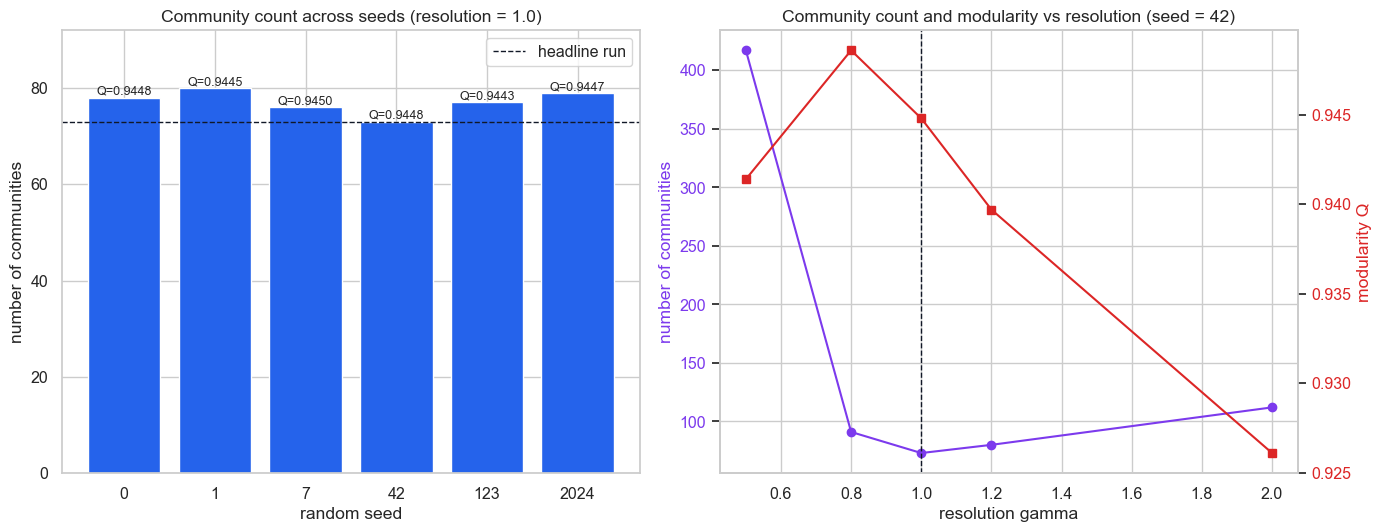

In [9]:
# --- figures/louvain_stability.png -----------------------------------------
seed_df = stability[stability['experiment'] == 'seed sweep'].sort_values('seed')
res_df = stability[stability['experiment'] == 'resolution sweep'].sort_values('resolution')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

bars = axes[0].bar(seed_df['seed'].astype(str), seed_df['num_communities'], color='#2563eb')
for bar, q in zip(bars, seed_df['modularity']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'Q={q:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].axhline(num_communities, color='#111827', linestyle='--', linewidth=1,
                label='headline run')
axes[0].set_xlabel('random seed')
axes[0].set_ylabel('number of communities')
axes[0].set_title(f'Community count across seeds (resolution = {LOUVAIN_RESOLUTION})')
axes[0].margins(y=0.15)
axes[0].legend()

axes[1].plot(res_df['resolution'], res_df['num_communities'], marker='o', color='#7c3aed')
axes[1].set_xlabel('resolution gamma')
axes[1].set_ylabel('number of communities', color='#7c3aed')
axes[1].tick_params(axis='y', labelcolor='#7c3aed')
axes[1].axvline(LOUVAIN_RESOLUTION, color='#111827', linestyle='--', linewidth=1)
twin = axes[1].twinx()
twin.plot(res_df['resolution'], res_df['modularity'], marker='s', color='#dc2626')
twin.set_ylabel('modularity Q', color='#dc2626')
twin.tick_params(axis='y', labelcolor='#dc2626')
twin.grid(False)
axes[1].set_title(f'Community count and modularity vs resolution (seed = {LOUVAIN_SEED})')

plt.tight_layout()
plt.savefig(FIGURES / 'louvain_stability.png', dpi=FIG_DPI)
plt.show()


## 9. A second opinion: label propagation

The original script also ran **label propagation**, and we keep it as a cross-check. It's a completely different idea: every node starts in its own community, then repeatedly adopts the label held by the majority of its neighbors, until no node wants to change. It doesn't explicitly maximize anything - there's no modularity term in it - so agreement between the two methods is meaningful evidence that the structure is real and not a byproduct of the modularity objective.

Two caveats, mentioned because they matter for interpreting the comparison. First, `networkx`'s `label_propagation_communities` ignores edge weights, so it sees topology alone while Louvain sees service intensity; the two methods answer slightly different questions. Second, label propagation is known to produce very different *granularity* - often one very large community plus a long tail of small ones - another reminder that "number of communities" is a property of the method at least as much as it is a property of the network. We score its partition with the same modularity function so the two are on a comparable scale, and reuse the same size-based renumbering.

In [10]:
# --- Label propagation (unweighted, cross-check only) ----------------------
if RUN_LABEL_PROPAGATION:
    lp_communities = list(nx.community.label_propagation_communities(Gc))
    partition_lp = relabel_by_size(
        {node: cid for cid, members in enumerate(lp_communities) for node in members})
    modularity_lp = partition_modularity(Gc, partition_lp, resolution=LOUVAIN_RESOLUTION)
    lp_sizes = pd.Series(Counter(partition_lp.values())).sort_values(ascending=False)
    ari_lp = float(adjusted_rand_score(base_labels, [partition_lp[n] for n in node_order]))
    print(f'label propagation communities : {int(lp_sizes.size):,}')
    print(f'label propagation modularity  : {modularity_lp:.4f}   (Louvain: {modularity:.4f})')
    print(f'largest community             : {int(lp_sizes.iloc[0]):,} stations')
    print(f'agreement with Louvain (ARI)  : {ari_lp:.3f}')
else:
    partition_lp, modularity_lp, ari_lp = {}, None, None
    print('label propagation skipped (RUN_LABEL_PROPAGATION = False)')


label propagation communities : 8,035
label propagation modularity  : 0.5469   (Louvain: 0.9448)
largest community             : 113 stations
agreement with Louvain (ARI)  : 0.020


## 10. Exporting the station-level community assignment

The first of the required tables. One row per station in the **entire** graph - not just the largest component - carrying its identity, coordinates, region, metro, degree, and its community under each algorithm. Stations outside the largest component (and, if label propagation is skipped, every station in the label propagation column) get `-1`, a sentinel value meaning "not assigned in this run" and never a real community id. Keeping the stations that were excluded from the analysis inside the file, rather than dropping them, lets later notebooks join on the full station list without silently losing rows.

In [11]:
# --- tables/community_assignments.csv --------------------------------------
assign_df = pd.DataFrame([{
    'stop_id': n,
    'stop_name': G.nodes[n]['stop_name'],
    'lat': G.nodes[n]['lat'],
    'lon': G.nodes[n]['lon'],
    'region': G.nodes[n]['region'],
    'metro': G.nodes[n]['metro'],
    'degree': G.degree(n),
    'community_louvain': partition.get(n, -1),
    'community_lp': partition_lp.get(n, -1),
} for n in G.nodes()])
assign_df = assign_df.sort_values(['community_louvain', 'degree'],
                                  ascending=[True, False]).reset_index(drop=True)
assign_df.to_csv(TABLES / 'community_assignments.csv', index=False, encoding='utf-8-sig')

print(f"saved {TABLES / 'community_assignments.csv'}  ({len(assign_df):,} rows)")
print(f"unassigned stations (community -1): {int((assign_df['community_louvain'] == -1).sum()):,}")
assign_df.head(10)


saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\08_community_detection\tables\community_assignments.csv  (30,463 rows)
unassigned stations (community -1): 226


,stop_id,stop_name,lat,lon,region,metro,degree,community_louvain,community_lp
0,37338,לוד,31.947694,34.879159,Center,Tel Aviv,8,-1,-1
1,37292,תל אביב ההגנה,32.053978,34.784839,Center,Tel Aviv,8,-1,-1
2,37362,הרצליה,32.163558,34.817406,Center,Tel Aviv,8,-1,-1
3,37380,חיפה מרכז,32.822306,34.997177,North,Haifa,7,-1,-1
4,37372,בנימינה,32.514386,34.949573,North,Periphery,6,-1,-1
5,37376,חוף הכרמל,32.793600,34.957404,North,Haifa,6,-1,-1
6,41293,קרית מוצקין,32.833133,35.070030,North,Haifa,6,-1,-1
7,37314,באר שבע צפון,31.262089,34.809287,South,Beer Sheva,5,-1,-1
8,37368,חדרה מערב,32.438199,34.899321,Center,Periphery,5,-1,-1
9,37316,קרית גת,31.603526,34.777955,Center,Periphery,4,-1,-1


## 11. Describing each community - and labeling it from the data

The second required table. For each community we compute, in a single pass over the edges (so the cost stays linear rather than quadratic in the number of communities, as it would if a `subgraph` were called for each community as in the original script):

* **Size** - the number of stations, and its share of the analyzed component.
* **Internal edges / internal weight** - segments and trips that stay inside the community.
* **External edges / external weight** - segments and trips that leave it. The ratio `external_weight / (internal_weight + external_weight)` is a conductance-style measure of how much a community "leaks": close to 0 means a self-contained cluster, close to 1 means a group that mainly talks to the outside.
* **Boundary stations** - how many of its stations have at least one neighbor in another community.
* **Centroid** - the mean latitude and longitude over its stations that have usable coordinates, which determines where the label is placed on the map.
* **Dominant region / dominant metro** and their shares - the modal value of the `region` and `metro` attributes that notebook 01 assigned geographically.
* **Hub station** - the member with the highest weighted degree, i.e. the busiest station in the community.

The **label** is derived and never hard-coded: it's the community's own modal metro joined to its modal region (with deduplication when the two overlap), and it's only as good as the geography assigned upstream in notebook 01 - a rough latitude/longitude rule with four metropolitan disks, not an administrative registry. The `dominant_metro_share` column is exported precisely so the reader can see when a label is weak: a community whose modal metro covers only half its stations is a genuine mix that a one-word label flattens, and it should be read together with the hub station's name.

In [12]:
# --- tables/community_summary.csv ------------------------------------------
groups = groups_from_partition(partition)

internal_edges = Counter(); internal_weight = Counter()
external_edges = Counter(); external_weight = Counter()
boundary_nodes = defaultdict(set)

for u, v, data in Gc.edges(data=True):
    cu, cv = partition[u], partition[v]
    w = data.get(WEIGHT_ATTR, 1)
    if cu == cv:
        internal_edges[cu] += 1
        internal_weight[cu] += w
    else:
        for c in (cu, cv):
            external_edges[c] += 1
            external_weight[c] += w
        boundary_nodes[cu].add(u)
        boundary_nodes[cv].add(v)

weighted_degree = dict(Gc.degree(weight=WEIGHT_ATTR))


def _mode(values):
    """Most common non-empty value and its share; ('', 0.0) when nothing is present."""
    counts = Counter(v for v in values if v)
    if not counts:
        return '', 0.0
    value, count = counts.most_common(1)[0]
    return value, round(count / len(values), 4)


def _label(metro, region):
    """Derived, data-driven community label: modal metro joined with modal region."""
    parts = [p for p in (metro, region) if p]
    return ' / '.join(dict.fromkeys(parts)) if parts else 'unlabelled'


rows = []
for cid, members in sorted(groups.items(), key=lambda kv: kv[0]):
    members = sorted(members)
    lats = [G.nodes[n]['lat'] for n in members if G.nodes[n]['lat'] is not None]
    lons = [G.nodes[n]['lon'] for n in members if G.nodes[n]['lon'] is not None]
    metro, metro_share = _mode([G.nodes[n]['metro'] for n in members])
    region, region_share = _mode([G.nodes[n]['region'] for n in members])
    hub = max(members, key=lambda n: (weighted_degree.get(n, 0), Gc.degree(n)))
    iw, ew = int(internal_weight[cid]), int(external_weight[cid])
    rows.append({
        'community_id': cid,
        'label': _label(metro, region),
        'size': len(members),
        'share_of_component': round(len(members) / Gc.number_of_nodes(), 5),
        'internal_edges': int(internal_edges[cid]),
        'external_edges': int(external_edges[cid]),
        'internal_weight': iw,
        'external_weight': ew,
        'external_weight_ratio': round(ew / (iw + ew), 4) if (iw + ew) else None,
        'boundary_stations': len(boundary_nodes[cid]),
        'boundary_share': round(len(boundary_nodes[cid]) / len(members), 4),
        'centroid_lat': round(float(np.mean(lats)), 4) if lats else None,
        'centroid_lon': round(float(np.mean(lons)), 4) if lons else None,
        'dominant_region': region,
        'dominant_region_share': region_share,
        'dominant_metro': metro,
        'dominant_metro_share': metro_share,
        'hub_stop_id': hub,
        'hub_stop_name': G.nodes[hub]['stop_name'],
    })

summary_df = pd.DataFrame(rows).sort_values('size', ascending=False).reset_index(drop=True)
summary_df.to_csv(TABLES / 'community_summary.csv', index=False, encoding='utf-8-sig')

print(f"saved {TABLES / 'community_summary.csv'}  ({len(summary_df):,} communities)")
print('communities per dominant metropolitan area (labels are derived, not hard-coded):')
print(summary_df['dominant_metro'].value_counts().to_string())
summary_df.head(TOP_N)[['community_id', 'label', 'size', 'internal_edges', 'external_edges',
                        'external_weight_ratio', 'dominant_metro_share', 'hub_stop_name']]


saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\08_community_detection\tables\community_summary.csv  (73 communities)
communities per dominant metropolitan area (labels are derived, not hard-coded):
dominant_metro
Periphery     27
Tel Aviv      20
Jerusalem     12
Haifa         11
Beer Sheva     3


,community_id,label,size,internal_edges,external_edges,external_weight_ratio,dominant_metro_share,hub_stop_name
0,0,Beer Sheva / South,1334,1961,189,0.0181,0.9640,דואר/יצחק רגר
1,1,Periphery / North,854,1346,86,0.0305,1.0000,ת. מרכזית ק''ש/הורדה
2,2,Periphery / North,842,1245,41,0.0153,0.9299,הרב קוק/ז'בוטינסקי
3,3,Tel Aviv / Center,820,1302,178,0.0204,0.7280,הרצל/עולי הגרדום
4,4,Periphery / North,820,1204,109,0.0273,0.9720,היכל התרבות/חטיבה תש''ע
5,5,Periphery / North,812,1200,126,0.0640,0.7389,סח'נין עיריה
6,6,Periphery / Center,788,1321,249,0.0623,0.9454,מלכי ישראל/יציאה צפונית
7,7,Tel Aviv / Center,775,1381,193,0.0453,0.9935,בי''ס חב''ד ב' לבנים/יוספטל
8,8,Periphery / North,741,1147,50,0.0191,0.9946,מרכז רסקו
9,9,Jerusalem,665,1042,170,0.0632,0.9910,אצטדיון טדי/א''ס ביתר


## 12. Inter-community bridge stations

The third required table, and the part that links this notebook back to the project's resilience question. A station is an **inter-community bridge** when at least one of its neighbors sits in another community: this is a point where a journey is forced to leave one cluster and enter another. Note that this is a *different* concept from the graph-theory bridges of notebook 03 - those were edges whose removal disconnects the graph entirely, whereas these are stations that carry inter-cluster traffic and whose loss would force long detours even when the network stays technically connected. A station can be one, the other, both, or neither, and it's worth joining the two tables.

For each such station we record how many **distinct** communities its neighborhood touches (the original script's key measure), how many of the edges incident to it cross a boundary, its degree and weighted degree, and what share of its traffic is inter-community. Ranking by the number of distinct communities first and by crossing weight second surfaces the stations that are both structurally central and heavily used - the ones a resilience study should test first. A station touching many communities is a transfer junction between regional systems; a station touching only one other community but carrying enormous crossing weight is a single high-volume corridor.

The cell also collects the two network-level quantities that indicate how tightly the clusters are bound together: the share of edges and the share of total trip weight that cross a community boundary.

In [13]:
# --- tables/inter_community_bridges.csv ------------------------------------
label_of = dict(zip(summary_df['community_id'], summary_df['label']))

bridge_rows = []
for node in Gc.nodes():
    own = partition[node]
    other_comms = set()
    crossing_edges = 0
    crossing_weight = 0
    for nb in Gc.neighbors(node):
        cid = partition[nb]
        if cid != own:
            other_comms.add(cid)
            crossing_edges += 1
            crossing_weight += Gc[node][nb].get(WEIGHT_ATTR, 1)
    if not other_comms:
        continue
    wdeg = weighted_degree.get(node, 0)
    bridge_rows.append({
        'stop_id': node,
        'stop_name': G.nodes[node]['stop_name'],
        'own_community': own,
        'own_community_label': label_of.get(own, ''),
        'connected_communities': len(other_comms),
        'crossing_edges': crossing_edges,
        'crossing_weight': int(crossing_weight),
        'degree': Gc.degree(node),
        'weighted_degree': int(wdeg),
        'crossing_weight_share': round(crossing_weight / wdeg, 4) if wdeg else None,
        'lat': G.nodes[node]['lat'],
        'lon': G.nodes[node]['lon'],
        'region': G.nodes[node]['region'],
        'metro': G.nodes[node]['metro'],
    })

bridges_df = (pd.DataFrame(bridge_rows)
              .sort_values(['connected_communities', 'crossing_weight'], ascending=False)
              .reset_index(drop=True))
bridges_df.to_csv(TABLES / 'inter_community_bridges.csv', index=False, encoding='utf-8-sig')

cross_edges = sum(1 for u, v in Gc.edges() if partition[u] != partition[v])
cross_weight = sum(d.get(WEIGHT_ATTR, 1) for u, v, d in Gc.edges(data=True)
                   if partition[u] != partition[v])
component_weight = sum(d.get(WEIGHT_ATTR, 1) for _, _, d in Gc.edges(data=True))

print(f"saved {TABLES / 'inter_community_bridges.csv'}  ({len(bridges_df):,} stations)")
print(f'boundary stations     : {len(bridges_df):,} of {Gc.number_of_nodes():,} '
      f'({len(bridges_df) / Gc.number_of_nodes():.2%} of the analysed component)')
print(f'cross-community edges : {cross_edges:,} of {Gc.number_of_edges():,} '
      f'({cross_edges / Gc.number_of_edges():.2%})')
print(f'cross-community trips : {cross_weight:,} of {component_weight:,} '
      f'({cross_weight / component_weight:.2%} of all trip weight)')
bridges_df.head(TOP_N)[['stop_id', 'stop_name', 'own_community_label', 'connected_communities',
                        'crossing_edges', 'crossing_weight', 'degree']]


saved C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\08_community_detection\tables\inter_community_bridges.csv  (3,407 stations)
boundary stations     : 3,407 of 30,237 (11.27% of the analysed component)
cross-community edges : 3,686 of 51,523 (7.15%)
cross-community trips : 487,126 of 15,202,043 (3.20% of all trip weight)


,stop_id,stop_name,own_community_label,connected_communities,crossing_edges,crossing_weight,degree
0,41133,מחלף חמד,Jerusalem,19,28,2466,62
1,41132,מחלף חמד,Jerusalem,16,23,2271,44
2,7562,שדרות בית הלל/כניסה לעיר,Tel Aviv / Center,14,25,1414,29
3,23418,רבי יהודה הנשיא/כניסה לעיר,Tel Aviv / Center,14,22,687,24
4,9048,בן גוריון/שערי ירושלים,Jerusalem,13,16,1357,41
5,9046,ויצמן/גבעת שאול,Jerusalem,12,18,3286,36
6,7444,דרך האר''י/ כביש 375,Jerusalem / Center,12,20,1956,29
7,748,מחלף קסם,Tel Aviv / Center,12,18,1034,19
8,25419,רבי יהודה הנשיא/חוני המעגל,Tel Aviv / Center,12,17,350,21
9,14348,מחלף גהה/דרך ז'בוטינסקי,Tel Aviv / Center,11,14,1587,15


## 13. The community map

Every station in the analyzed component is plotted at its real longitude and latitude, colored by community; stations outside the component are drawn in light gray so the reader can see what was excluded from the analysis. This is the deciding figure for whether the partition means anything: if Louvain found real structure, the colors have to form **spatially contiguous patches**, because the communities of a transport network are geographic by definition - buses connect places that are near each other. A random, confetti-like scatter would indicate that the partition is numerical noise.

Two deliberate changes from the original script. First, it built its colormap with `tab20.resampled(n)`, which *interpolates* between the twenty categorical colors and produces dozens of muddy, nearly identical shades once there are more communities than colors. We instead cycle over three 20-color qualitative maps (60 visually distinct colors) modulo the community id: the colors do repeat, but because the ids are ordered by size, the large communities that dominate the picture all get different colors. The map is meant to show *contiguity*, not to let the reader identify a specific community by its color - the annotation labels do that job. Second, the original filtered coordinates with `if lat and lon`, which silently drops a station sitting exactly at `0.0` and, worse, keeps `NaN` values; we explicitly check that a value is present and finite.

The few large communities are annotated in place, at their centroids, with the data-derived labels.

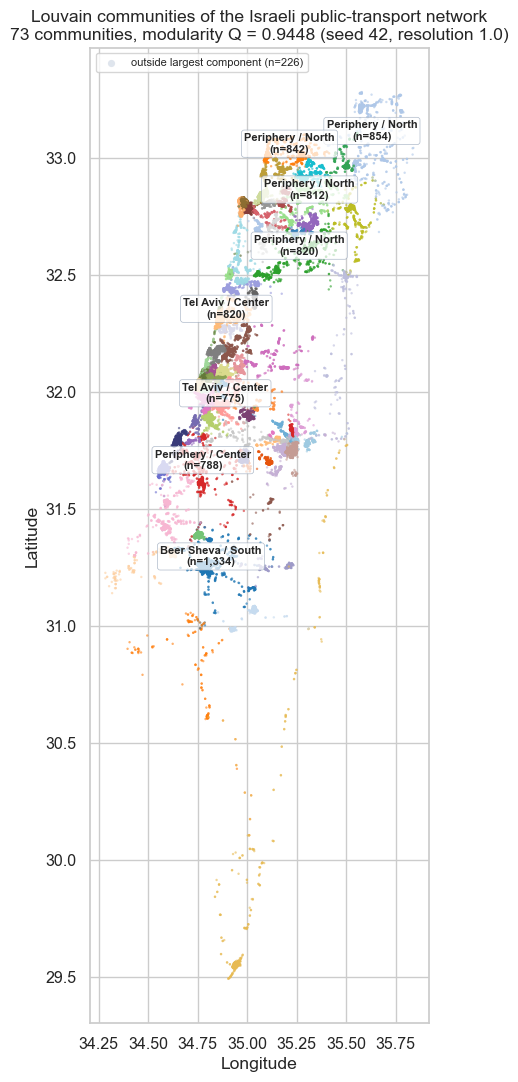

plotted 30,237 of 30,237 analysed stations (0 lack usable coordinates)


In [14]:
# --- figures/community_map_louvain.png -------------------------------------
def has_coords(node):
    """True only when both coordinates are present and finite (0.0 included)."""
    lat, lon = G.nodes[node]['lat'], G.nodes[node]['lon']
    return (lat is not None and lon is not None
            and np.isfinite(lat) and np.isfinite(lon))


qualitative = [c for name in ('tab20', 'tab20b', 'tab20c')
               for c in matplotlib.colormaps[name].colors]

plot_nodes = [n for n in Gc.nodes() if has_coords(n)]
if not plot_nodes:
    raise ValueError('No station in the analysed component carries usable coordinates - '
                     'check nodes.csv from notebook 02.')
plot_lons = [G.nodes[n]['lon'] for n in plot_nodes]
plot_lats = [G.nodes[n]['lat'] for n in plot_nodes]
plot_cols = [qualitative[partition[n] % len(qualitative)] for n in plot_nodes]
bg_nodes = [n for n in G.nodes() if n not in partition and has_coords(n)]

fig, ax = plt.subplots(figsize=(8.5, 11))
if bg_nodes:
    ax.scatter([G.nodes[n]['lon'] for n in bg_nodes], [G.nodes[n]['lat'] for n in bg_nodes],
               s=MAP_POINT_SIZE, color='#cbd5e1', alpha=0.6, linewidths=0,
               label=f'outside largest component (n={len(bg_nodes):,})')
ax.scatter(plot_lons, plot_lats, s=MAP_POINT_SIZE, color=plot_cols,
           alpha=MAP_ALPHA, linewidths=0)

for _, row in summary_df.head(ANNOTATE_TOP).iterrows():
    if row['centroid_lat'] is None or row['centroid_lon'] is None:
        continue
    ax.annotate(f"{row['label']}\n(n={int(row['size']):,})",
                (row['centroid_lon'], row['centroid_lat']),
                fontsize=8, fontweight='bold', ha='center', zorder=6,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.75,
                          edgecolor='#94a3b8', linewidth=0.5))

ax.set_aspect(1 / np.cos(np.deg2rad(float(np.mean(plot_lats)))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Louvain communities of the Israeli public-transport network\n'
             f'{num_communities:,} communities, modularity Q = {modularity:.4f} '
             f'(seed {LOUVAIN_SEED}, resolution {LOUVAIN_RESOLUTION})')
if bg_nodes:
    ax.legend(loc='upper left', fontsize=8, markerscale=3)
plt.tight_layout()
plt.savefig(FIGURES / 'community_map_louvain.png', dpi=FIG_DPI)
plt.show()

print(f'plotted {len(plot_nodes):,} of {Gc.number_of_nodes():,} analysed stations '
      f'({Gc.number_of_nodes() - len(plot_nodes):,} lack usable coordinates)')


## 14. The community size distribution

Two views of how the stations are distributed. The **left panel** ranks the largest communities by size, labeled with the data-derived label and the busiest station of each, so the reader sees immediately whether the partition is dominated by a few metropolitan blocks. The **right panel** shows the full rank-size distribution on logarithmic axes - all the communities, not just the top ones - and this is the honest view: it reveals whether there's a long tail of tiny communities and roughly how fast the size falls off with rank.

The tail matters for interpreting section 8. Communities of a handful of stations are exactly the ones that merge or split when the seed changes, so a fat tail of tiny communities is a direct visual explanation for the total number being unstable while the large blocks are not. The horizontal reference line marks a size of ten stations, the threshold reported in section 7's key printout.

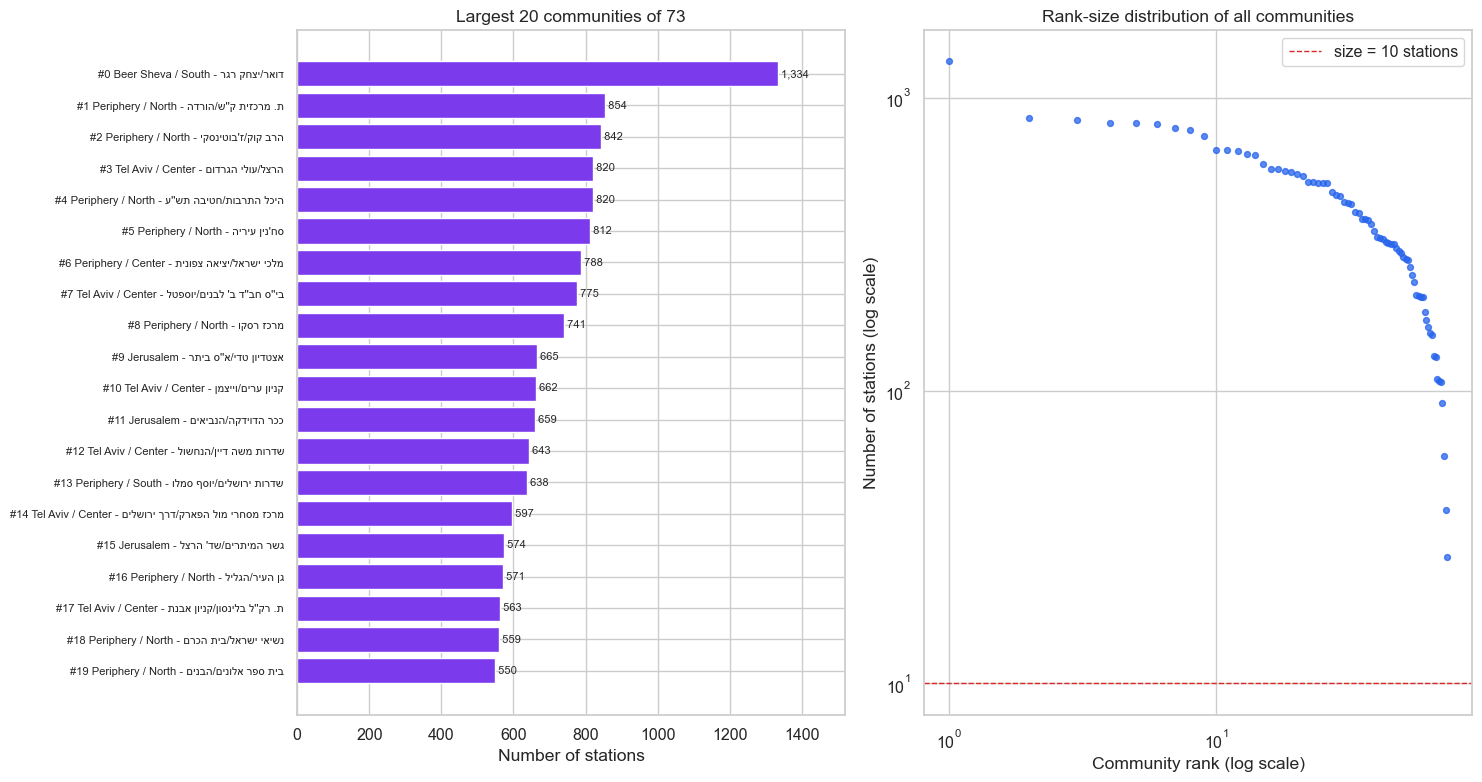

count      73.000000
mean      414.205479
std       243.447688
min        27.000000
25%       235.000000
50%       383.000000
75%       559.000000
max      1334.000000


In [15]:
# --- figures/community_size_distribution.png -------------------------------
top = summary_df.head(TOP_N).iloc[::-1]
top_labels = [f'#{int(cid)} {lab} - {hub}' for cid, lab, hub
              in zip(top['community_id'], top['label'], top['hub_stop_name'])]

sizes_sorted = summary_df['size'].to_numpy()
ranks = np.arange(1, len(sizes_sorted) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

bars = axes[0].barh(range(len(top)), top['size'].to_numpy(), color='#7c3aed')
axes[0].set_yticks(range(len(top)))
axes[0].set_yticklabels(top_labels, fontsize=8)
for bar, val in zip(bars, top['size'].to_numpy()):
    axes[0].text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 f' {int(val):,}', va='center', fontsize=8)
axes[0].set_xlabel('Number of stations')
axes[0].set_title(f'Largest {len(top)} communities of {num_communities:,}')
axes[0].margins(x=0.14)

axes[1].scatter(ranks, sizes_sorted, s=18, color='#2563eb', alpha=0.75)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].axhline(10, color='#dc2626', linestyle='--', linewidth=1, label='size = 10 stations')
axes[1].set_xlabel('Community rank (log scale)')
axes[1].set_ylabel('Number of stations (log scale)')
axes[1].set_title('Rank-size distribution of all communities')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'community_size_distribution.png', dpi=FIG_DPI)
plt.show()

print(summary_df['size'].describe().to_string())


## 15. Where the boundary stations are

The last figure places the highest-ranked inter-community bridge stations on the map, with size and color set by the number of communities they touch, over a faint background of the whole network. Because communities in a transport network are geographic, these points should fall on the *seams* between the colored patches of section 13 - the corridors connecting one metropolitan cluster to another. Those seams are the places where a failure doesn't just delay a journey but forces it to leave its cluster entirely, which is why this table feeds the resilience notebooks.

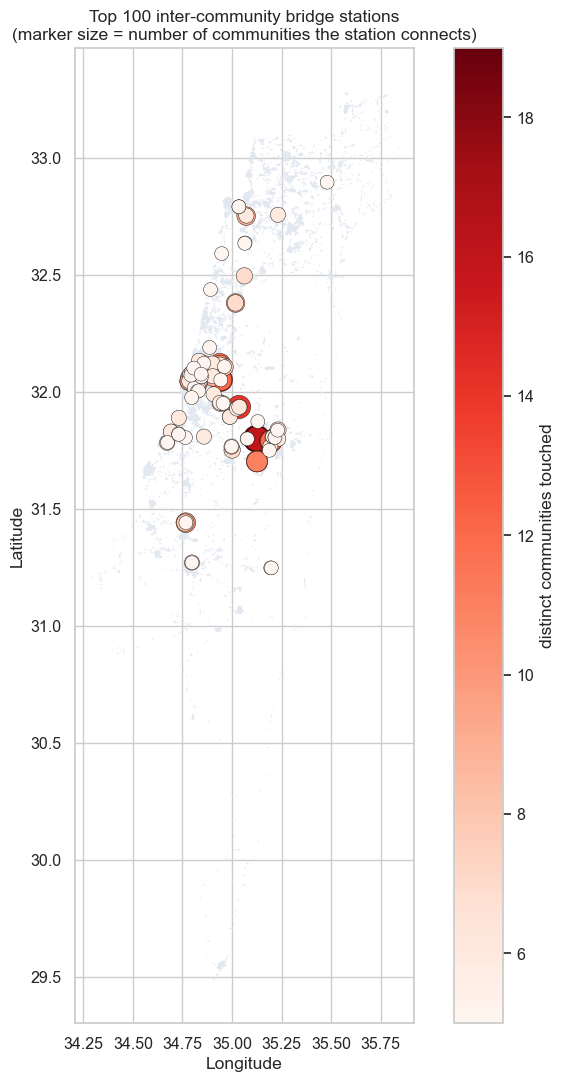

In [16]:
# --- figures/inter_community_bridges_map.png -------------------------------
top_bridges = bridges_df.dropna(subset=['lat', 'lon']).head(100)

fig, ax = plt.subplots(figsize=(8.5, 11))
bg = [n for n in G.nodes() if has_coords(n)]
ax.scatter([G.nodes[n]['lon'] for n in bg], [G.nodes[n]['lat'] for n in bg],
           s=1, color='#e2e8f0', alpha=0.5, linewidths=0)
sc = ax.scatter(top_bridges['lon'], top_bridges['lat'],
                s=top_bridges['connected_communities'] * 20,
                c=top_bridges['connected_communities'], cmap='Reds',
                edgecolors='black', linewidths=0.3, zorder=5)
plt.colorbar(sc, ax=ax, label='distinct communities touched')
ax.set_aspect(1 / np.cos(np.deg2rad(float(np.mean(plot_lats)))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Top {len(top_bridges)} inter-community bridge stations\n'
             '(marker size = number of communities the station connects)')
plt.tight_layout()
plt.savefig(FIGURES / 'inter_community_bridges_map.png', dpi=FIG_DPI)
plt.show()


## 16. The key statistics

Everything worth citing from this stage, gathered into one dictionary and written both as JSON and as a single-row CSV file. Every field is computed above - and the seed, resolution, and backend are saved *alongside* the results precisely so a future reader can know which configuration produced them, the discipline whose absence caused the 91-vs-73 confusion in the first place.

In [17]:
# --- community_detection_summary.json --------------------------------------
summary = {
    'louvain_backend': LOUVAIN_BACKEND,
    'louvain_seed': LOUVAIN_SEED,
    'louvain_resolution': LOUVAIN_RESOLUTION,
    'weighted': True,
    'graph_nodes': G.number_of_nodes(),
    'graph_edges': G.number_of_edges(),
    'connected_components': len(components),
    'analysed_nodes': Gc.number_of_nodes(),
    'analysed_edges': Gc.number_of_edges(),
    'num_communities': num_communities,
    'modularity': round(modularity, 4),
    'largest_community_size': int(community_sizes.iloc[0]),
    'largest_community_share': round(float(community_sizes.iloc[0]) / Gc.number_of_nodes(), 4),
    'median_community_size': float(community_sizes.median()),
    'communities_under_10_stations': int((community_sizes < 10).sum()),
    'cross_community_edges': int(cross_edges),
    'cross_community_edge_share': round(cross_edges / Gc.number_of_edges(), 4),
    'cross_community_weight_share': round(cross_weight / component_weight, 4),
    'inter_community_stations': int(len(bridges_df)),
    'inter_community_station_share': round(len(bridges_df) / Gc.number_of_nodes(), 4),
    'max_communities_touched_by_one_station':
        int(bridges_df['connected_communities'].max()) if len(bridges_df) else 0,
    'seed_sweep_seeds': list(SEED_SWEEP),
    'seed_sweep_min_communities': int(seed_runs['num_communities'].min()),
    'seed_sweep_max_communities': int(seed_runs['num_communities'].max()),
    'seed_sweep_min_modularity': float(seed_runs['modularity'].min()),
    'seed_sweep_max_modularity': float(seed_runs['modularity'].max()),
    'seed_sweep_min_ari_vs_headline': float(seed_runs['ari_vs_headline'].min()),
    'label_propagation_communities': int(len(set(partition_lp.values()))) if partition_lp else None,
    'label_propagation_modularity': round(modularity_lp, 4) if modularity_lp is not None else None,
    'label_propagation_ari_vs_louvain': round(ari_lp, 4) if ari_lp is not None else None,
}

with open(STAGE / 'community_detection_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
flat = {k: (json.dumps(v) if isinstance(v, list) else v) for k, v in summary.items()}
pd.DataFrame([flat]).to_csv(TABLES / 'community_detection_summary.csv',
                            index=False, encoding='utf-8-sig')

print('saved:', STAGE / 'community_detection_summary.json')
for p in sorted(TABLES.iterdir()) + sorted(FIGURES.iterdir()):
    print(f'  {p.relative_to(STAGE)}  ({p.stat().st_size / 1024:,.0f} KB)')
pd.DataFrame({'metric': list(summary.keys()), 'value': [str(v) for v in summary.values()]})


saved: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\08_community_detection\community_detection_summary.json
  tables\community_assignments.csv  (2,453 KB)
  tables\community_detection_summary.csv  (1 KB)
  tables\community_summary.csv  (11 KB)
  tables\inter_community_bridges.csv  (382 KB)
  tables\louvain_stability.csv  (1 KB)
  figures\community_map_louvain.png  (239 KB)
  figures\community_size_distribution.png  (166 KB)
  figures\inter_community_bridges_map.png  (174 KB)
  figures\louvain_stability.png  (129 KB)


,metric,value
0,louvain_backend,python-louvain
1,louvain_seed,42
2,louvain_resolution,1.0
3,weighted,True
4,graph_nodes,30463
5,graph_edges,51772
6,connected_components,12
7,analysed_nodes,30237
8,analysed_edges,51523
9,num_communities,73


## Conclusions

* **The network does break into communities, and the modularity value is the claim worth making.** The main run prints its modularity, `Q`, in section 7; read it against the accepted benchmark by which values in roughly the 0.3-0.7 range indicate real community structure, while a value close to 0 would mean the partition is no better than chance. The modularity, not the community count, is the reproducible quantity - it barely moves across the seed sweep.

* **The number of communities isn't a property of the network.** This is the direct answer to the 91-vs-73 dispute, between the Hebrew summary report and the presentation's pipeline. Louvain is a stochastic greedy heuristic over a non-convex objective, so the seed alone moves the number while the modularity stays essentially flat and the adjusted Rand index against the main run stays high: the partition is stable, only the bookkeeping at its margins isn't. On top of that, the resolution `gamma` moves the number deliberately and by much more; running on the full graph instead of the largest connected component adds one community per isolated component (the exact offset is printed in section 6); and `python-louvain`, `networkx`, and igraph/Leiden reach different local optima from identical input. Each of the two earlier numbers is reproducible under some combination of these settings, which is why this notebook fixes the seed and the resolution, records the backend, and reports its own result instead of quoting a remembered number. **The right way to cite a Louvain result is "N communities at seed S, resolution R, implementation X, modularity Q", and never "N communities".**

* **The communities are geographic, and that's the meaningful sanity check.** The map colors form contiguous spatial patches rather than confetti, and the derived labels - each community's modal metro and modal region, computed at run time - line up with the country's metropolitan structure. This is what you'd expect from a transport network, where adjacency is limited by physical distance, and it's the central evidence that the partition is meaningful and not numerical noise. The caveat is that these labels inherit notebook 01's coarse latitude/longitude region rule and its four metropolitan disks, so a low `dominant_metro_share` in `community_summary.csv` flags a community whose one-word label really is an oversimplification.

* **The size distribution is very uneven, and the tail explains the instability.** A few large metropolitan communities hold most of the stations, while a long tail of small communities covers the periphery, as the rank-size panel shows. Those small communities are exactly the ones that merge or split between seeds, so the fat tail and the unstable number are the same phenomenon seen twice. It also follows that summary statistics across communities - a mean community size, for instance - are nearly meaningless here; show the distribution, don't average it.

* **The boundary stations are a minority, and that's the resilience finding.** Only a fraction of the stations have any neighbor in another community, and only a fraction of the trip weight crosses a community boundary; the exact shares are printed in section 12 and saved in the summary JSON. A network whose clusters are joined through a relatively small number of stations is efficient but exposed: those stations carry the inter-regional traffic, and the ones touching the most communities are the natural first candidates for the targeted-attack experiments in the robustness notebooks. Note that these are *not* the same objects as notebook 03's bridges - those were edges whose removal disconnects the graph, and these are stations carrying inter-cluster flow - and joining the two tables identifies the stations that are both.

* **Limitations, honestly.** The partition is derived from *scheduled trip counts in a single GTFS snapshot*, with no passenger loads, no timetable, no transfer times, and no walking links between nearby stations - two stations on opposite sides of the same junction are separate nodes unless a trip connects them, which fragments the graph in a way real passengers don't experience. Louvain also suffers from the known resolution limit: at `gamma = 1` it can't detect communities much smaller than the square root of the total edge weight, so genuinely small local clusters can be swallowed by their larger neighbors. Label propagation, which maximizes nothing and ignores weights, is reported alongside it as an independent check and not a competitor: where the two methods agree, we can talk about the structure with confidence; where they disagree, don't over-interpret the granularity of any single method.